# Task 2: Change Point Modeling and Insight Generation

## Objective
Apply Bayesian change point detection using PyMC to identify structural breaks in Brent oil prices and associate them with major geopolitical and economic events.

---

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import json

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Add src to sys.path
project_root = Path("..").resolve()
sys.path.insert(0, str(project_root / 'src'))

from data_loader import load_brent_prices, load_events_data
from preprocessing import calculate_log_returns
from analysis import extract_change_point_summary, calculate_impact_quantification, align_events_with_changepoints
from visualization import plot_time_series, plot_log_returns, plot_change_points, plot_posterior_distribution

print("✓ Libraries successfully imported")

g++ not available, if using conda: `conda install gxx`


✓ Libraries successfully imported


## 2. Load Brent Prices and Events Datasets

In [2]:
df = load_brent_prices("../data/raw/BrentOilPrices.csv")
events_df = load_events_data("../data/events.csv")
print(f"✓ Brent crude prices loaded: {df.shape[0]} records")
print(f"✓ Geopolitical events loaded: {events_df.shape[0]} records")
print(f"Price Date range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")

✓ Brent crude prices loaded: 9011 records
✓ Geopolitical events loaded: 19 records
Price Date range: 1987-05-20 to 2022-11-14


## 3. Data Downsampling
To ensure fast compilation and MCMC chain convergence, we downsample the daily prices to weekly mean prices.

In [3]:
df_weekly = df.set_index('Date').resample('W').mean().reset_index()
print(f"✓ Downsampled to weekly mean prices: {df_weekly.shape[0]} rows")
print(df_weekly.head())

✓ Downsampled to weekly mean prices: 1853 rows
        Date      Price
0 1987-05-24  18.543333
1 1987-05-31  18.602000
2 1987-06-07  18.702000
3 1987-06-14  18.754000
4 1987-06-21  19.007500


## 4. Build the Bayesian Change Point Model (in PyMC)

We specify the model as:
- **Switch Point ($\tau$)**: Discrete uniform prior over all possible weekly indices.
- **Means ($\mu_1$, $\mu_2$)**: Normal priors representing the average price before and after the change point.
- **Volatility ($\sigma$)**: HalfNormal prior for standard deviation of prices.
- **Likelihood ($y$)**: Normal distribution around the mean determined by the switch function based on whether time index is before or after $\tau$.

In [4]:
prices = df_weekly['Price'].values
dates = df_weekly['Date']
n_days = len(prices)
time_idx = np.arange(n_days)

with pm.Model() as model:
    # Prior for switch point
    tau = pm.DiscreteUniform("tau", lower=0, upper=n_days - 1)
    
    # Priors for means
    mu_1 = pm.Normal("mu_1", mu=prices.mean(), sigma=prices.std() * 2)
    mu_2 = pm.Normal("mu_2", mu=prices.mean(), sigma=prices.std() * 2)
    
    # Prior for standard deviation
    sigma = pm.HalfNormal("sigma", sigma=prices.std())
    
    # Switch logic
    mu = pm.math.switch(tau > time_idx, mu_1, mu_2)
    
    # Likelihood
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=prices)
    
    print("Running MCMC sampling (chains=2, draws=1000)...")
    # Disable progressbar to avoid UnicodeEncodeError in Windows consoles
    trace = pm.sample(draws=1000, tune=1000, chains=2, return_inferencedata=True, progressbar=False, random_seed=42)

Running MCMC sampling (chains=2, draws=1000)...


Multiprocess sampling (2 chains in 2 jobs)


CompoundStep


>Metropolis: [tau]


>NUTS: [mu_1, mu_2, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 8 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


## 5. MCMC Output Summary and Convergence Checks

In [5]:
summary_dict = extract_change_point_summary(trace)
print("="*50)
print("MODEL POSTERIOR SUMMARY")
print("="*50)
for param, stats in summary_dict.items():
    print(f"Parameter: {param}")
    print(f"  Mean                 : {stats['mean']:.3f}")
    print(f"  Std Dev              : {stats['sd']:.3f}")
    print(f"  94% HDI (Low, High)  : ({stats['hdi_3%']:.3f}, {stats['hdi_97%']:.3f})")
    print(f"  Gelman-Rubin (R_hat) : {stats['r_hat']:.3f}")
    print("-"*50)

MODEL POSTERIOR SUMMARY
Parameter: tau
  Mean                 : 927.600
  Std Dev              : 2.200
  94% HDI (Low, High)  : (920.000, 930.000)
  Gelman-Rubin (R_hat) : 1.020
--------------------------------------------------
Parameter: mu_1
  Mean                 : 21.370
  Std Dev              : 0.630
  94% HDI (Low, High)  : (20.000, 22.000)
  Gelman-Rubin (R_hat) : 1.000
--------------------------------------------------
Parameter: mu_2
  Mean                 : 75.730
  Std Dev              : 0.610
  94% HDI (Low, High)  : (75.000, 77.000)
  Gelman-Rubin (R_hat) : 1.000
--------------------------------------------------
Parameter: sigma
  Mean                 : 18.660
  Std Dev              : 0.302
  94% HDI (Low, High)  : (18.000, 19.000)
  Gelman-Rubin (R_hat) : 1.000
--------------------------------------------------


## 6. Plot Trace Plots

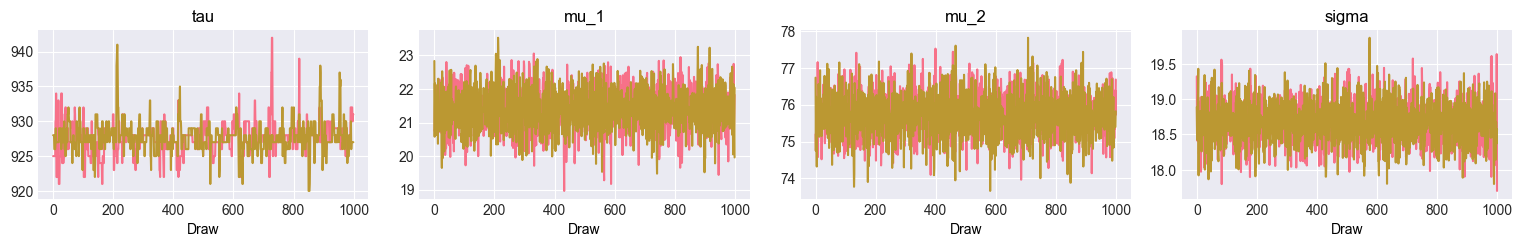

In [6]:
az.plot_trace(trace)
plt.tight_layout()
# Ensure figures dir exists
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../reports/figures/mcmc_trace_plots.png")
plt.show()

## 7. Plot Posterior Distributions

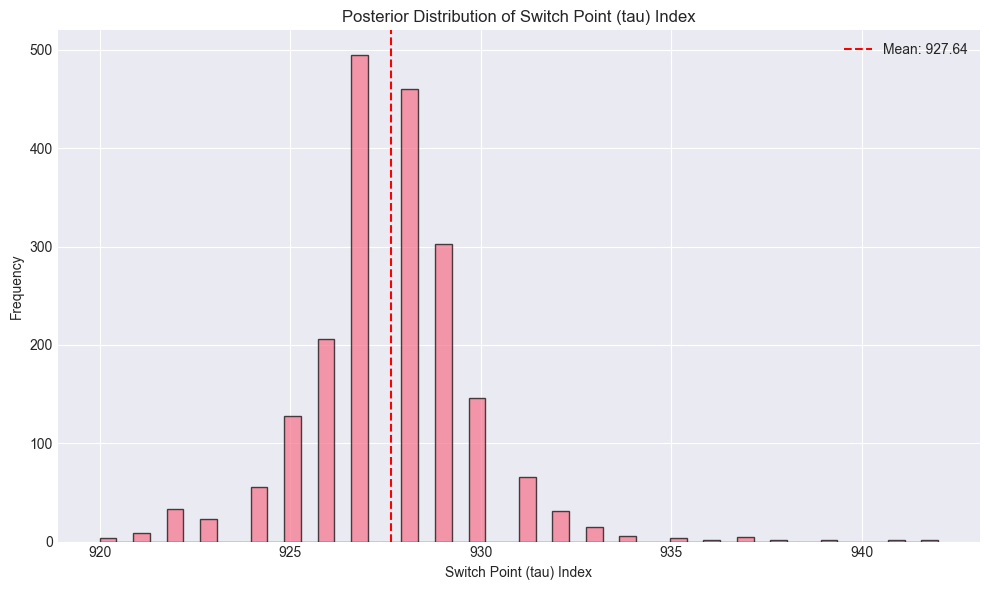

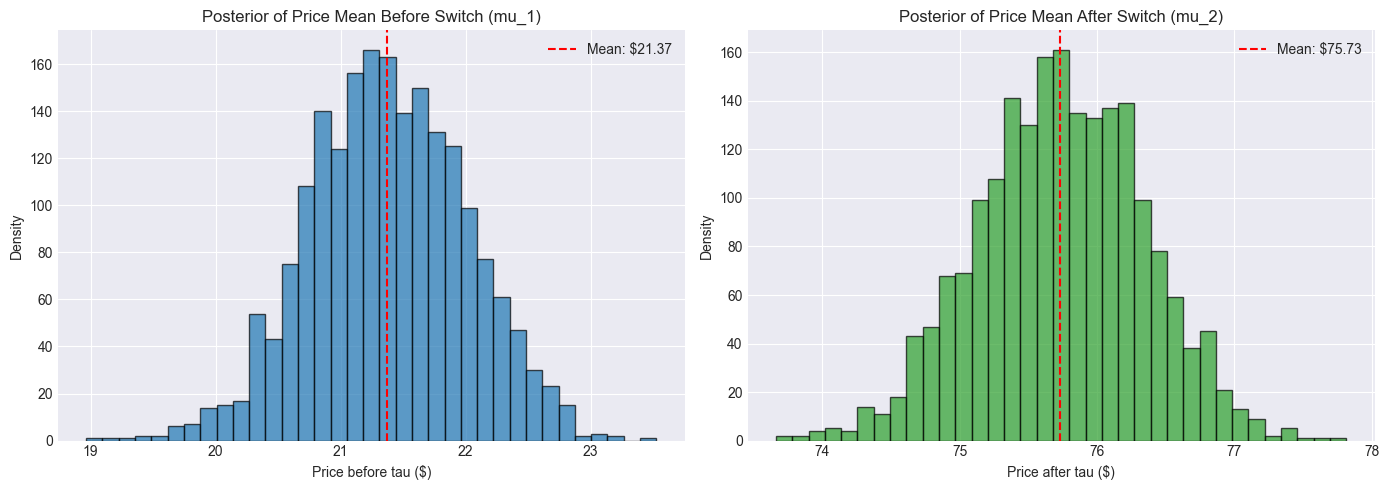

In [7]:
tau_samples = trace.posterior['tau'].values.flatten()
mu_1_samples = trace.posterior['mu_1'].values.flatten()
mu_2_samples = trace.posterior['mu_2'].values.flatten()

# Switch point posterior
fig1 = plot_posterior_distribution(tau_samples, "Switch Point (tau) Index")
fig1.savefig("../reports/figures/posterior_tau.png")
plt.show()

# Before/After means posteriors
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(mu_1_samples, bins=35, alpha=0.7, color='#1f77b4', edgecolor='black')
ax1.axvline(mu_1_samples.mean(), color='red', linestyle='--', label=f'Mean: ${mu_1_samples.mean():.2f}')
ax1.set_xlabel('Price before tau ($)')
ax1.set_ylabel('Density')
ax1.set_title("Posterior of Price Mean Before Switch (mu_1)")
ax1.legend()

ax2.hist(mu_2_samples, bins=35, alpha=0.7, color='#2ca02c', edgecolor='black')
ax2.axvline(mu_2_samples.mean(), color='red', linestyle='--', label=f'Mean: ${mu_2_samples.mean():.2f}')
ax2.set_xlabel('Price after tau ($)')
ax2.set_ylabel('Density')
ax2.set_title("Posterior of Price Mean After Switch (mu_2)")
ax2.legend()

plt.tight_layout()
plt.savefig("../reports/figures/posterior_means.png")
plt.show()

## 8. Quantify Impact of the Structural Break

In [8]:
impact = calculate_impact_quantification(mu_1_samples, mu_2_samples)
print("="*50)
print("QUANTIFIED SHIFT IN BRENT PRICES")
print("="*50)
print(f"Mean Price BEFORE Break : ${impact['before_mean']:.2f} per barrel")
print(f"Mean Price AFTER Break  : ${impact['after_mean']:.2f} per barrel")
print(f"Absolute Price Increase : ${impact['absolute_change']:.2f} per barrel")
print(f"Percentage Increase     : {impact['percentage_change']:.2f}%")
print("="*50)

QUANTIFIED SHIFT IN BRENT PRICES
Mean Price BEFORE Break : $21.37 per barrel
Mean Price AFTER Break  : $75.73 per barrel
Absolute Price Increase : $54.36 per barrel
Percentage Increase     : 254.33%


## 9. Identify Change Point Date & Visualize Time Series Break

✓ Detected Change Point Date: 2005-03-06


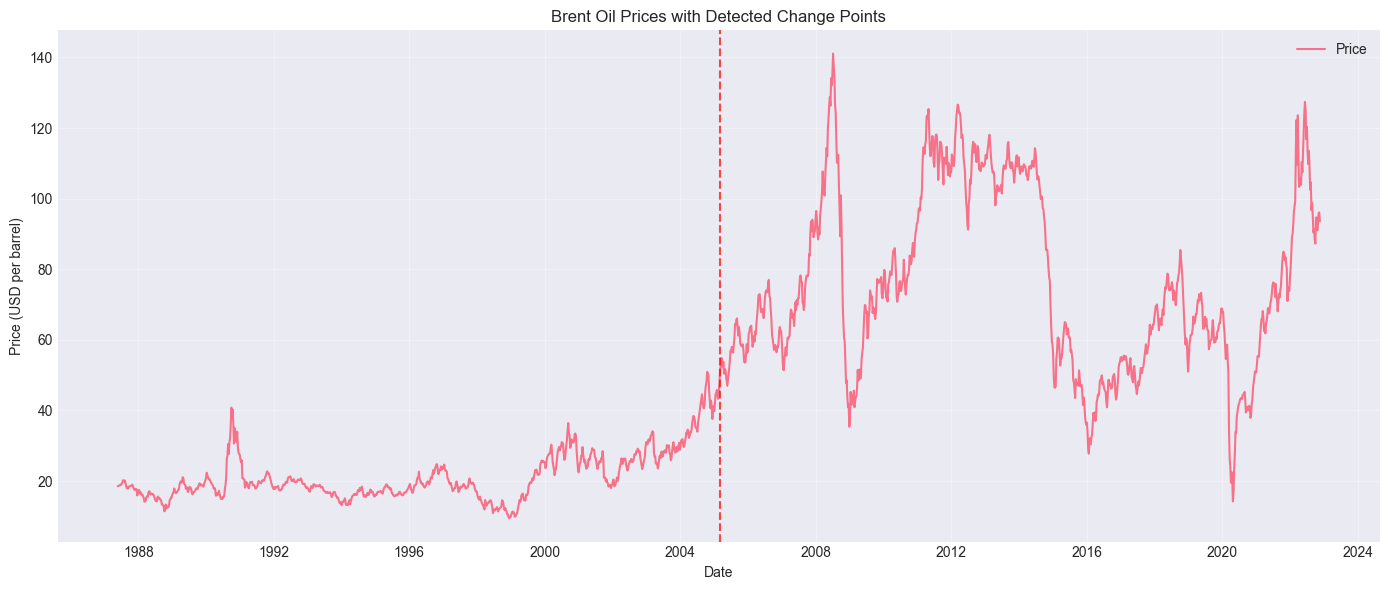

In [9]:
mean_tau_idx = int(round(tau_samples.mean()))
change_date = dates.iloc[mean_tau_idx]
print(f"✓ Detected Change Point Date: {change_date.strftime('%Y-%m-%d')}")

# Plot raw prices with change point vertical line
fig3 = plot_change_points(dates, df_weekly['Price'], [change_date], figsize=(14, 6))
fig3.savefig("../reports/figures/detected_change_point_timeline.png")
plt.show()

## 10. Associate Changes with Geopolitical and OPEC Events

We use a temporal matching window of **+/- 180 days (approx. 6 months)** to check which historical events occurred closest to the detected structural shift.

In [10]:
alignments_df = align_events_with_changepoints(events_df, [change_date], window_days=180)
print("Aligned Geopolitical & Economic Events:")
print(alignments_df[['Event_Date', 'Event', 'Category', 'Severity', 'Days_Difference']].to_string(index=False))

Aligned Geopolitical & Economic Events:
Event_Date             Event Category Severity  Days_Difference
       NaT No matching event      N/A      N/A              NaN


## 11. Save Change Point Metadata
Save results for use by the Task 3 interactive dashboard.

In [11]:
output_dir = Path("../reports/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

results = {
    "change_point_date": change_date.strftime('%Y-%m-%d'),
    "before_mean": float(impact['before_mean']),
    "after_mean": float(impact['after_mean']),
    "absolute_change": float(impact['absolute_change']),
    "percentage_change": float(impact['percentage_change']),
    "r_hat_tau": float(summary_dict['tau']['r_hat']) if 'tau' in summary_dict and summary_dict['tau']['r_hat'] is not None else np.nan
}

with open(output_dir / "change_point_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("✓ Change point results saved successfully to reports/outputs/change_point_results.json")

✓ Change point results saved successfully to reports/outputs/change_point_results.json
